In [2]:
%load_ext autoreload
%autoreload 2
%cd ~/code/entityrepresentations/

/home/morand/code/entityrepresentations


/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
import transformers
import transformer_lens as tl 
from transformer_lens import HookedTransformer
from importlib import reload
import torch, os, gc, sys, pathlib
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tikzplotlib      # need matplotlib<3.6

#our own code
import utils 
from LabelExtractor import eval_model, infer_entities
from processResults import *


Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


## Parameters

In [3]:
model_name = "gpt2-small" # 117M ok
model_name = "pythia-2.8b"#ok !
model_name = "mistralai/Mistral-7B-v0.1" # ok JZ a100 8cpus | 
model_name = "gpt2-large" # 774M ok
model_name = "gpt2-medium" # 302M ok
model_name = "gpt2-xl" # 1.5B ok
model_name = "phi-1_5"  # 1.5B ok
model_name = "phi-2" # 2,5B ok 12cpus nope, gpu 24cpus ok

dataset_name= "WebNLG"
dataset_name= "TACRED"
dataset_name= "CoNLL2003"

dtype = torch.bfloat16
dtype = torch.float32

with_context = True
with_context = False

In [4]:
xp_path = pathlib.Path.home() / "experiments_JeanZay" # load results
xp_paths= os.listdir(xp_path / "jobs")      #get all experiments directories
jobs_path = xp_path / "jobs" / xp_paths[0]
results = loadResults(jobs_path)            #get jobs
results = results[(results["model_name"]==model_name) &
                  (results["dataset_name"]==dataset_name) &
                  (results["with_context"]==with_context) ]
print(f"Loaded {len(results)} results")

#get jobs for linear filters
xp_lin = 'labelextractor.learnlinearfilter'
results_linear = loadResults(xp_path / "jobs" / xp_lin)

100%|███████████████████████████████████████████████████████████████████████████| 2010/2010 [01:42<00:00, 19.59it/s]


Loaded 363 results


100%|█████████████████████████████████████████████████████████████████████████████| 830/830 [00:36<00:00, 22.82it/s]


## Load Model

In [5]:
# del model
gc.collect()
torch.cuda.empty_cache()

In [6]:
# del model
#check if model variable exists
if not 'model' in locals():
    model = HookedTransformer.from_pretrained(
                                    model_name, 
                                    trust_remote_code = True, 
                                    low_cpu_mem_usage = True, 
                                    device_map='auto',
                                    move_to_device=False,
                                    fold_ln=False,
                                    fold_value_biases=False,
                                    center_writing_weights=False,
                                    center_unembed=False,
                                    dtype=dtype,
                                    )
    dim = model.QK.shape[-1]
print(model)
model.eval()
model = model.cuda()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model phi-2 into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out

# Data

In [7]:
# !wget https://lre.baulab.info/data/factual/landmark_in_country.json
# !wget https://lre.baulab.info/data/factual/product_by_company.json
# !wget https://lre.baulab.info/data/factual/country_largest_city.json
# !wget https://lre.baulab.info/data/factual/star_constellation.json
# !wget https://lre.baulab.info/data/commonsense/task_done_by_tool.json 
# !wget https://lre.baulab.info/data/factual/person_father.json
# !wget https://lre.baulab.info/data/factual/person_occupation.json
# !wget https://lre.baulab.info/data/commonsense/object_superclass.json
# !wget https://lre.baulab.info/data/bias/person_native_language.json


In [8]:
from utils import EntityReprDataset
import pandas as pd
import json
# Load the JSON file
data_path = Path("datasets")
json_file = "task_done_by_tool.json" 
json_file = "country_largest_city.json"
json_file = "person_mother.json"
json_file = "product_by_company.json"
json_file = "object_superclass.json"
json_file = "person_father.json"
json_file = "person_occupation.json"
json_file = "star_constellation.json" 
json_file = "person_native_language.json" 
json_file = "landmark_in_country.json"

data_name = json_file.split(".")[0]
with open(data_path / json_file, 'r') as file:
    data = json.load(file)
samples = data['samples']
print(f"Loaded {len(samples)} samples")
print(samples[0])

prompts = [
    "{s} can be found in {o}.", "In {o}, you'll find {s}.", "{s} is situated in {o}.", "{o} is home to {s}.", "{s} stands in {o}.", " famous {s} is located in {o}.", "{o} hosts {s}.", "{s} resides in {o}.", "In country of {o} lies {s}.", "{s} is placed in {o}.", "{s} is a landmark in {o}.", "You can visit {s} in {o}.", "{s} has its location in {o}.", "{o} is where {s} is found.", "One of {o}'s main attractions is {s}.", "{s} is in {o}.", "{s} is based in {o}.", "You will find {s} in {o}."]
prompts = [
    "{s} is a product of {o}", "{s} is produced by {o}","{s} is manufactured by {o}","{o} makes {s}","{o} produces {s}","{s} was created by {o}",]
prompts = [
    "The largest city in {s} is {o}","{o} is the largest city in {s}","The biggest city of {s} is {o}","The largest city of {s} is {o}","The biggest city in {s} is {o}","{o} is the biggest city in {s}",]
prompts = ["{s}'s mother's name is {o}"]
prompts = ["{s}'s father's name is {o}"]

prompts = ["{s}'s native tongue is {o}"]
prompts = [ prompt.replace("{}","{s}") + " {o}" for prompt in data['prompt_templates']]


joint_df = []
for it in samples:
    prompt = prompts[np.random.randint(0, len(prompts))]
    s = it['subject']
    o = it['object']
    joint_df.append({
        "text": prompt.format(s=s, o=o),
        "subject": s,
        "object": o,
        })

print(f"Created {len(joint_df)} samples")
joint_df = pd.DataFrame(joint_df)
joint_df.head()

Loaded 836 samples
{'subject': 'Autonomous University of Madrid', 'object': 'Spain'}
Created 836 samples


,text,subject,object
0,Autonomous University of Madrid is in the coun...,Autonomous University of Madrid,Spain
1,Pochepsky District is in the country of Russia,Pochepsky District,Russia
2,Kuala Langat is in the country of Malaysia,Kuala Langat,Malaysia
3,Wanne-Eickel Central Station is in the country...,Wanne-Eickel Central Station,Germany
4,Hohenlohe-Langenburg is in the country of Germany,Hohenlohe-Langenburg,Germany


Found 91 unique labels dict_keys(['Spain', 'Russia', 'Malaysia', 'Germany', 'France', 'Philippines', 'Sweden', 'Mexico', 'India', 'Azerbaijan', 'Latvia', 'Switzerland', 'Fiji', 'Pakistan', 'Honduras', 'Canada', 'Ireland', 'Italy', 'Japan', 'Vietnam', 'Nepal', 'Israel', 'Nigeria', 'Greece', 'Belgium', 'Norway', 'Australia', 'Qatar', 'Brazil', 'Ethiopia', 'Romania', 'Iran', 'Hungary', 'Indonesia', 'Somalia', 'Uganda', 'Syria', 'Bolivia', 'Poland', 'Turkey', 'Guatemala', 'Netherlands', 'Finland', 'Ukraine', 'Kenya', 'Singapore', 'Bulgaria', 'Rwanda', 'Venezuela', 'Bahrain', 'Thailand', 'Cyprus', 'Sudan', 'Estonia', 'Libya', 'Serbia', 'Argentina', 'Chile', 'Denmark', 'Portugal', 'Lebanon', 'Belarus', 'Slovenia', 'Peru', 'Yemen', 'Lithuania', 'Luxembourg', 'Iraq', 'Liberia', 'Madagascar', 'Bangladesh', 'Kosovo', 'Tanzania', 'Croatia', 'Bahamas', 'Tunisia', 'Egypt', 'Oman', 'Austria', 'Colombia', 'Afghanistan', 'Cambodia', 'Algeria', 'Ghana', 'Malta', 'Haiti', 'Taiwan', 'Armenia', 'Morocco',

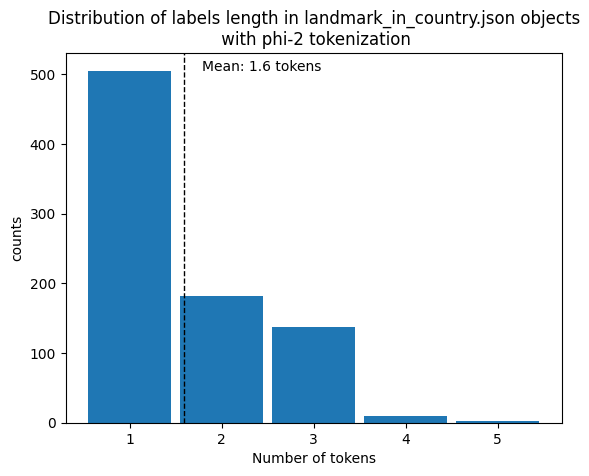

In [9]:
tokenizer = model.tokenizer

key = 'object'
labels = {}
for i, item in joint_df.iterrows():
    if item[key] not in labels:
        str_tokens = model.to_str_tokens(item[key], prepend_bos=False)
        #remove the special tokens
        # str_tokens = [tok for tok in str_tokens if tok not in [tokenizer.eos_token]]
        labels[item[key]] = str_tokens

print(f"Found {len(labels)} unique labels", labels.keys())
# augment dataset set with label lenght 
joint_df['tokenized_ent'] = joint_df[key].apply(lambda x: labels[x])

#plot the distribution of labels length
m = 10
#plot the distribution of labels length, with shifted x axis
lengths = [len(it['tokenized_ent']) for i, it in joint_df.iterrows()]
labels_len, counts = np.unique(lengths, return_counts=True)
joint_df.drop(columns=['tokenized_ent'], inplace=True)
# print(f"Test set: {len(lengths)} items for {len(labels)} unique labels")

plt.bar(labels_len, counts, width=.9, align='center')
#place ticks every 1
plt.xticks(np.arange(min(labels_len), max(labels_len)+1, 1.0))
## add mean and std
mean = np.mean(lengths)
plt.axvline(mean, color='k', linestyle='dashed', linewidth=1)
plt.text(mean + .2, np.max(counts) , f"Mean: {mean:.1f} tokens")
plt.title(f"Distribution of labels length in {json_file} objects\n with {model_name.split('/')[-1]} tokenization")
plt.xlabel("Number of tokens")
plt.ylabel("counts")
# tikzplotlib.save(f"./plots/EntityLengths_{dataset_name}_{model_name.split('/')[-1]}.tex")
plt.show()


## Filter items for which the model has no factual knowledge

In [10]:
def filter_known_facts(joint_df):
    """Filter out known facts from the joint df
    """
    if type(joint_df) == pd.DataFrame: joint_df = joint_df.to_dict(orient='records')
    for itm in tqdm(joint_df):
        obj = itm['object']
        subj = itm['subject']
        prompt = obj.join(itm['text'].split(obj)[:-1]).strip()
        #infer max five tokens
        gen = model.generate(prompt, max_new_tokens=5, temperature=0, return_type="str", verbose=False)
        gen = gen.split(prompt)[1].strip()
        itm['generated'] = gen
        itm['is_correct'] = gen.startswith(obj)
        # print(f"Prompt: {prompt}\nGenerated: {gen}\nIs correct: {itm['is_correct']}\n")
    joint_df = pd.DataFrame(joint_df)
    joint_df.head()

    ## filter out the correct ones
    known_df = joint_df[joint_df['is_correct']]
    print(f"Found {len(known_df)} correct samples on {len(joint_df)} samples in total")

    return known_df

known_df = filter_known_facts(joint_df)
# known_df = joint_df

100%|█████████████████████████████████████████████████████████████████████████████| 836/836 [04:57<00:00,  2.81it/s]

Found 556 correct samples on 836 samples in total


In [11]:
joint_df.head(15)

,text,subject,object
0,Autonomous University of Madrid is in the coun...,Autonomous University of Madrid,Spain
1,Pochepsky District is in the country of Russia,Pochepsky District,Russia
2,Kuala Langat is in the country of Malaysia,Kuala Langat,Malaysia
3,Wanne-Eickel Central Station is in the country...,Wanne-Eickel Central Station,Germany
4,Hohenlohe-Langenburg is in the country of Germany,Hohenlohe-Langenburg,Germany
5,Bastille is in the country of France,Bastille,France
6,Shablykinsky District is in the country of Russia,Shablykinsky District,Russia
7,Manila Light Rail Transit System is in the cou...,Manila Light Rail Transit System,Philippines
8,Valdemarsvik is in the country of Sweden,Valdemarsvik,Sweden
9,Ozumba is in the country of Mexico,Ozumba,Mexico


## Augment with representations

In [12]:
layer = 3
layer = 31
layer = 10
layer = 25

method = 'average'
method = 'in_context'

def augment_with_reprs(joint_df, model, layer=0, method='after_context', batch_size=32, verbose=False):
    """
    Augment the df with representations of the entities in the text
    """
    for key in ['subject', 'object']:
        if verbose: print(f"Extracting representations for {key} with method {method}")
        joint_df["entity"] = joint_df[key] # get key into entity col 
        #drop the key column
        new_key = f"{key}_repr"
        if new_key in joint_df.columns:
            joint_df.drop(columns=[new_key], inplace=True)
        data = joint_df.to_dict(orient='records')
        repr_df = EntityReprDataset(
            data=data,
            max_length=500,
            max_ent_length=500
            )
        if method == 'average':
            repr_df.augment_with_avg_repr(model, layer=layer, batch_size=32, method='in_context', verbose=verbose)
        else:
            repr_df.augment_with_repr(model, layer=layer, batch_size=32, method=method, verbose=verbose)
        #back to pandas dataframe
        joint_df = pd.DataFrame(repr_df.data)
        # rename the columns
        joint_df.rename(columns={
            'representation': new_key,
        }, inplace=True)
        joint_df.drop(columns=['entity'], inplace=True)

    return joint_df

known_df = augment_with_reprs(known_df, model, layer=layer, method=method, batch_size=32, verbose=True)

Extracting representations for subject with method in_context


100%|███████████████████████████████████████████████████████████████████████████████| 18/18 [00:04<00:00,  4.48it/s]


Extracting representations for object with method in_context


100%|███████████████████████████████████████████████████████████████████████████████| 18/18 [00:05<00:00,  3.19it/s]


## Optionally use the linear filter

In [13]:
from processResults import get_taskVec

filter_reps = True   
filter_reps = False

normalization = True
normalization = False

filter_subject_reps = False

if filter_reps:
    path = get_taskVec(results_linear, model_name, layer=layer, with_context=with_context)
    print(f"Loading model from {str(path).split('/')[-1]}")
    linear_filter = torch.load(path)
    #cast the model to the correct type
    linear_filter = linear_filter.type(dtype).cuda()

    with torch.no_grad():
        rep_cleaner = lambda x: linear_filter(x.cuda()).detach().cpu()
        normalize = lambda x: x / torch.norm(x, p=2)
        #map the representations to the correct type
        # joint_dataset['subject_repr'] = joint_dataset['subject_repr'].apply(lambda x: linear_filter(x.cuda()).detach().cpu())
        known_df['object_repr'] = known_df['object_repr'].apply(rep_cleaner)
        if filter_subject_reps: known_df['subject_repr'] = known_df['subject_repr'].apply(rep_cleaner)

        if normalization:
            known_df['object_repr'] = known_df['object_repr'].apply(normalize)
            if filter_subject_reps: known_df['subject_repr'] = known_df['subject_repr'].apply(normalize)
    

In [14]:
known_df.head(5)

,text,subject,object,generated,is_correct,id,subject_repr,object_repr
0,Autonomous University of Madrid is in the coun...,Autonomous University of Madrid,Spain,Spain. It is a,True,0,"[tensor(0.1738), tensor(-2.5569), tensor(3.721...","[tensor(0.7625), tensor(-0.9386), tensor(4.326..."
1,Pochepsky District is in the country of Russia,Pochepsky District,Russia,Russia. It is one,True,1,"[tensor(2.0412), tensor(0.6449), tensor(2.9176...","[tensor(2.2005), tensor(0.1275), tensor(1.1879..."
2,Kuala Langat is in the country of Malaysia,Kuala Langat,Malaysia,Malaysia. It is a,True,2,"[tensor(0.7343), tensor(-3.1758), tensor(-0.75...","[tensor(-1.9697), tensor(-1.5650), tensor(1.82..."
3,Wanne-Eickel Central Station is in the country...,Wanne-Eickel Central Station,Germany,Germany. It is a,True,3,"[tensor(2.4829), tensor(-1.5981), tensor(1.631...","[tensor(0.9638), tensor(-0.8247), tensor(2.779..."
4,Hohenlohe-Langenburg is in the country of Germany,Hohenlohe-Langenburg,Germany,Germany. It is a,True,4,"[tensor(2.5927), tensor(-3.1058), tensor(-3.00...","[tensor(1.0648), tensor(-1.1770), tensor(3.766..."


## Test Train split

In [15]:
#separrate the df into train and test
from sklearn.model_selection import train_test_split
N_train = 50
test_size = (len(known_df) - N_train) / len(known_df)
train_df, test_df = train_test_split(known_df, test_size=test_size, random_state=42)

# #to list 
# train_df = train_df.to_dict(orient='records')
# test_df = test_df.to_dict(orient='records')

#test if some landmarks are in the test set
train_subjects = set([it for it in train_df['subject'] ])
test_subjects = set([it for it in test_df['subject'] ])

print("Train subjects: ", len(train_subjects))
print("Test subjects: ", len(test_subjects))
print("Common subjects: ", len(train_subjects.intersection(test_subjects)))
 

Train subjects:  50
Test subjects:  506
Common subjects:  0


# Training linear model
in this scetion we train a linear model that will try to map representations of landmarks to their countries.

In [16]:
dim = model.QK.shape[-1]
linear_model = torch.nn.Linear(dim, dim, bias=True)
#initialize the linear model with identity
linear_model.weight.data = torch.eye(dim).type(dtype)
linear_model.bias.data = torch.zeros(dim, dtype=dtype)
linear_model = linear_model.cuda()

hist = []
#freeze the model and the task vector
for param in model.parameters():
    param.requires_grad = False

Training on 2 batches of size 25
Epoch: 1, Batch: 2, Loss: 4.100701808929443, lr: 0.1
Epoch: 201, Batch: 402, Loss: 0.018323605880141258, lr: 0.1
Epoch: 401, Batch: 802, Loss: 0.0036424892023205757, lr: 0.1
Epoch: 601, Batch: 1202, Loss: 0.0010938592022284865, lr: 0.1
Epoch: 801, Batch: 1602, Loss: 0.0009308903245255351, lr: 0.1
Epoch: 1001, Batch: 2002, Loss: 9.801300620893016e-05, lr: 0.1
Epoch: 1201, Batch: 2402, Loss: 0.0005951527273282409, lr: 0.1
Epoch: 1401, Batch: 2802, Loss: 0.00037983895163051784, lr: 0.1
Epoch: 1601, Batch: 3202, Loss: 0.00013752139057032764, lr: 0.1
Epoch: 1801, Batch: 3602, Loss: 0.00015583923959638923, lr: 0.1
Epoch: 2001, Batch: 4002, Loss: 2.655839125509374e-06, lr: 0.05
Epoch: 2201, Batch: 4402, Loss: 4.244364390615374e-05, lr: 0.05
Epoch: 2401, Batch: 4802, Loss: 6.819377449573949e-05, lr: 0.05
Epoch: 2601, Batch: 5202, Loss: 2.6901358069153503e-05, lr: 0.05
Epoch: 2801, Batch: 5602, Loss: 4.4204414734849706e-05, lr: 0.05
Epoch: 3001, Batch: 6002, Los

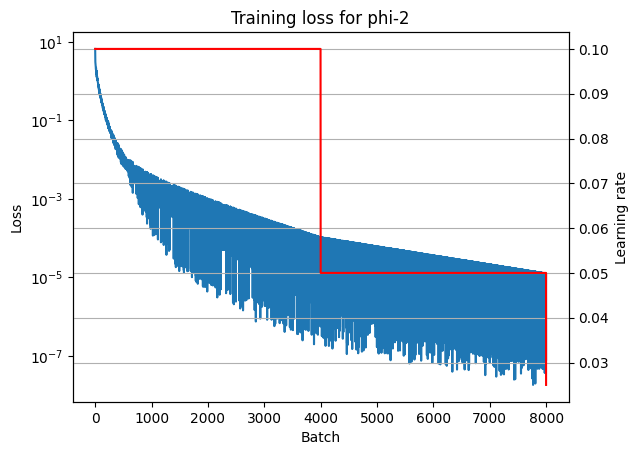

In [17]:
from torch.utils.data import DataLoader

epochs = 4000
log_every = 200
batch_per_epoch = 2
batch_size = N_train // batch_per_epoch
lr = 1e-1

grad_clip = 1e1

# optimizer
# optim = torch.optim.Adam(linear_model.parameters(), lr=lr)
optim = torch.optim.SGD(linear_model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()
# criterion = torch.nn.CosineEmbeddingLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=epochs * batch_per_epoch // 2, gamma=0.5)

#dataloader from datasets
train_loader = DataLoader(train_df.to_dict(orient='records'), batch_size=batch_size, shuffle=True)
print(f"Training on {len(train_loader)} batches of size {batch_size}")
# print(train_loader.dataset[0])

for epoch in range(epochs):
    for batch in train_loader:
        # Zero the gradients
        optim.zero_grad()
        
        subjects_reps = batch['subject_repr'].cuda()
        objects_reps = batch['object_repr'].cuda()
        y = torch.ones(objects_reps.shape[0], device="cuda")
        # print(subjects_reps.shape, objects_reps.shape)
        # Project augmented_batch representations using matrix P
        projected = linear_model(subjects_reps)
        
        # Compute the loss between projected_batch and objects_reps
        # loss = criterion(projected, objects_reps, y)
        loss = criterion(projected, objects_reps)
        loss.backward()
        # Clip the gradients
        torch.nn.utils.clip_grad_norm_(linear_model.parameters(), grad_clip)
        optim.step()
        scheduler.step()

        # Log the loss
        hist.append(
            {
                "epoch": epoch,
                "batch": len(hist),
                "loss": loss.item(),
                "lr": optim.param_groups[0]['lr']
            }
        )
    if epoch % log_every == 0:
        print(f"Epoch: {epoch+1}, Batch: {len(hist)}, Loss: {loss.item()}, lr: {optim.param_groups[0]['lr']}")

#plot the loss
#clear the plot
plt.clf()
plt.plot([it['loss'] for it in hist])
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.yscale('log')
#add athoer y axis for lr   
plt.twinx()
plt.ylabel("Learning rate")
plt.plot([it['lr'] for it in hist], color='r')

plt.grid()
plt.title(f"Training loss for {model_name}")
plt.show()


### Evaluate the model

In [ ]:
fileName = get_taskVec(results, 
                       model_name, 
                       layer=layer, 
                       dataset_name=dataset_name, 
                       with_context = with_context)

TaskVec = torch.load(fileName)
#cast to dtype
TaskVec = TaskVec.to(dtype)
print("TaskVec loaded from ", fileName)

In [ ]:
from LabelExtractor import evaluateTV

with torch.no_grad():
    test_dataset = [
        {   'entity': item['object'],
            'subject': item['subject'],
            'object': item['object'],
            'representation': linear_model(item['subject_repr'].cuda()).detach().cpu(),
            'text': item['text'],
            'id': i,
        } for i, item in enumerate(test_df.to_dict(orient='records'))#+ train_dataset)
        ]

metrics = evaluateTV(model, 
                          TaskVec, 
                          test_dataset,
                          with_context=with_context,
                          b_size=23)
print(f"metric for generation on {json_file}: ",metrics)

100%|█████████████████████████████████████████████████████████████████████████| 506/506 [00:00<00:00, 563696.63it/s]

metric for generation on landmark_in_country.json:  {'Partial Match': 0.7252964426877471, 'Exact Match': 0.7035573122529645, 'Chr-F': 67.32027839108211, 'Version': 1.2}


# Training Specific TaskVec

In [30]:

use_pretrained = False
use_pretrained = True

entity_key = 'subject'
target_key = 'object'
repr_key = 'subject_repr'

dtype = model.W_U.dtype
hist = []

# to list 
train_dataset = train_df.to_dict(orient='records')
test_dataset = test_df.to_dict(orient='records')

#test if some landmarks are in the test set
train_subjects = set([it for it in train_df['subject'] ])
test_subjects = set([it for it in test_df['subject'] ])

print("Train subjects: ", len(train_subjects))
print("Test subjects: ", len(test_subjects))
print("Common subjects: ", len(train_subjects.intersection(test_subjects)))
 
#rename the keys
train_dataset = [{
    "representation": it[repr_key],
    "subject": it[entity_key],
    "entity": it[target_key], 
    "object": it[target_key], 
    "text" : it['text'],
    "id" : i,
    } for i, it in enumerate(train_dataset)]

test_dataset = [{
    "representation": it[repr_key],
    "subject": it[entity_key],
    "entity": it[target_key], 
    "object": it[target_key], 
    "text" : it['text'],
    "id" : i,
    } for i, it in enumerate(test_dataset)]

#TODO Test with pretrained TV !

# create Task Vector
if use_pretrained:
    fileName = get_taskVec(results, 
                       model_name, 
                       layer=layer, 
                       dataset_name=dataset_name, 
                       with_context = with_context)

    TaskVec = torch.load(fileName)
    #cast to dtype
    TaskVec = TaskVec.to(dtype).detach().requires_grad_()
    #make it leaf tensor 
    print("TaskVec loaded from ", fileName)
else:
    TaskVec = torch.normal(mean=0, std=1.0, size=(1,dim), requires_grad=True, dtype=dtype)
    print("Created new TaskVec")

# TaskVec = torch.ones((1,d), requires_grad=True)
for param in model.parameters():
    param.requires_grad = False

Train subjects:  50
Test subjects:  506
Common subjects:  0
found 11 jobs for layer 25 of phi-2 without context on CoNLL2003
found ['TaskVec_phi-2_l25_e10.0.pth'] 
TaskVec loaded from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/a75424571c3e24aec0b7fb81cd11198a07793363c60d51c147000d4330255c27/TaskVec_phi-2_l25_e10.0.pth


/home/morand/ipykernel_2860370/1308017975.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  TaskVec = torch.load(fileName)


Resuming training TaskVec on CoNLL2003 for layer 25 of phi-2 without context...


 60%|████████████████████████████████████████████████                                | 6/10 [00:04<00:03,  1.02it/s]

Epoch 22.5,  Batch 5/10, Loss: 0.356, Test Acc: 0.926, lr:0.005
 0.926 is the best accuracy so far, saving TaskVec ...


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.16it/s]


Epoch 23.0,  Batch 10/10, Loss: 0.138, Test Acc: 0.926, lr:0.005


 60%|████████████████████████████████████████████████                                | 6/10 [00:04<00:04,  1.00s/it]

Epoch 23.5,  Batch 5/10, Loss: 0.256, Test Acc: 0.924, lr:0.005


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.15it/s]

Epoch 24.0,  Batch 10/10, Loss: 0.180, Test Acc: 0.924, lr:0.005
Training done, best accuracy: 0.9264705964163238, saving best TaskVec ...


Text(0, 0.5, 'Accuracy')

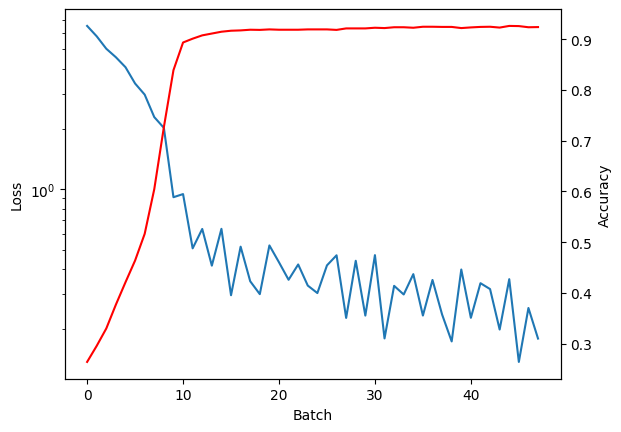

In [40]:
#Training params
lr = 5e-3
batch_size = 5
epochs = 2
log_per_epoch = 2
with_context = False

def train_TaskVec(model, 
        TaskVec, 
        with_context:bool,
        train_dataset, 
        test_dataset, 
        epochs=10, 
        lr=1e-2, 
        batch_size=5, 
        log_per_epoch=2, 
        hist=None,
        prepend_bos=True, 
        first_token_only = False
        ):
    """ Train the TaskVec on the train_dataset and test on the test_dataset. 
    Args:
    - model: the model to use for training
    - TaskVec: the task vector to train
    - with_context: if True, the model has access to the context to generate the entity mention
    - train_dataset: the training dataset MUST HAVE ['representation', 'subject', 'entity', 'text'] keys
    """
    if hist and type(hist) == list: 
        last_epoch = hist[-1]["epoch"]
    else :
        hist = []
        last_epoch = 0

    # sanity check for datasets
    for key in ['representation', 'subject', 'entity', 'text']:
        if key not in train_dataset[0].keys():
            raise ValueError(f"train_dataset must have a '{key}' key")
        if key not in test_dataset[0].keys():
            raise ValueError(f"test_dataset must have a '{key}' key")
        
    dtype = model.W_U.dtype
    rep_idx = 1 if prepend_bos else 0 
    eos_tok = model.tokenizer.eos_token_id
    eos_tok_str = model.tokenizer.eos_token
    replace_hook_name = tl.utils.get_act_name('embed') #pos_embed for gpt2 ... 

    train_dataloader =   DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataloader  =   DataLoader(test_dataset, batch_size=10, shuffle=True)
    len_loader = len(train_dataloader)
    n_log = len_loader // log_per_epoch
    optim = torch.optim.Adam([TaskVec], lr=lr)
    # optim = torch.optim.SGD([TaskVec], lr=lr)
    # criterion = nn.CrossEntropyLoss()
    
    #Cosine annealing scheduler
    # buffer to store best taskVec
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, len_loader//2, eta_min=lr/10)
    best_TaskVec = torch.zeros_like(TaskVec)

    gc.collect()
    torch.cuda.empty_cache()
    print(f"{'Resuming' if hist else 'Starting'} training TaskVec on {dataset_name} for layer {layer} of {model_name} with{'out' if not with_context else ''} context...")
    for epoch in range(epochs):
        epoch += last_epoch
        b_count = 0
        m_loss = 0
        for batch in tqdm(train_dataloader):
            # print( batch)
            b_count += 1
            entities = batch["entity"]
            subjects = batch[entity_key]
            texts = batch["text"]
            reps = batch["representation"].squeeze(1).cuda()
            b_size = reps.shape[0]
            b_taskVec = TaskVec.repeat(b_size,1).cuda()
            
            if first_token_only:
                entities = [toks[0] for toks in model.to_str_tokens(entities,prepend_bos=False)]
            else:    
                entities = [ent + eos_tok_str for ent in entities] # take whole label add eos token

            if with_context:
                        prompts = [txt + "_ >" for txt in texts]
                        context_toks = model.to_tokens(prompts, prepend_bos=prepend_bos, padding_side="left") 
                        entities_toks = model.to_tokens(entities, prepend_bos=False, padding_side="right")
                        inputs = torch.cat([context_toks, entities_toks], dim=1)
                        rep_idx = context_toks.shape[1] - 2
            else:
                rep_idx = 1 if prepend_bos else 0 
                prompts = ["_ > " + ent for ent in entities]
                inputs = model.to_tokens(prompts, prepend_bos=prepend_bos,)

            rep_idxs = torch.tensor(b_size * [rep_idx])
            taskVec_idxs = torch.tensor(b_size * [rep_idx + 1])
            targets = inputs[:,rep_idx+1:] #don't take the '<eos>', <context>, '_' tokens into account

            # print(prompts, entities,subjects)
            # break
            logits = model.run_with_hooks(
                    inputs,
                    return_type = "logits",
                    fwd_hooks=[
                        (replace_hook_name, utils.get_replace_with_rep_hook(reps, rep_idxs)), # replace '_' by the subject Representation
                        (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, taskVec_idxs)) # replace 'called' by TaskVec Representation
                        ]
                ,)

            # LM Loss and optimization 
            loss = model.loss_fn(logits[:, rep_idx+1:,:], targets) # take only the loss on the entity tokens
            loss.backward()
            optim.step()
            optim.zero_grad()
            m_loss += loss.item()
            # scheduler.step()
            
            if b_count % n_log == 0:
                m_loss = m_loss / (len_loader // log_per_epoch)
                e = epoch + b_count/len_loader
                acc = eval_model(
                                model,
                                TaskVec,
                                test_loader=test_dataloader, 
                                first_token_only=first_token_only, 
                                with_context=with_context,
                                prepend_bos=prepend_bos)
                lr = scheduler.get_last_lr()[0]
                print(f"Epoch {e:.1f},  Batch {b_count}/{len_loader}, Loss: {m_loss:.3f}, Test Acc: {acc:.3f}, lr:{lr:.3f}")
                
                #save best taskVec according to test accuracy
                if hist and acc >= max([h["test accuracy"] for h in hist]):
                    print(f" {acc:.3f} is the best accuracy so far, saving TaskVec ...")
                    best_TaskVec[:] = TaskVec[:]

                hist.append({"epoch":e, "loss": m_loss, "test accuracy": acc, "lr":lr})
                m_loss = 0
    
    #save the best taskVec
    print(f"Training done, best accuracy: {max([h['test accuracy'] for h in hist])}, saving best TaskVec ...")
    TaskVec = best_TaskVec.detach().cpu()
    return hist


#train 
hist = train_TaskVec(model, 
        TaskVec, 
        with_context=with_context,
        train_dataset=train_dataset, 
        test_dataset=test_dataset, 
        epochs=epochs, 
        lr=lr, 
        batch_size=batch_size, 
        log_per_epoch=log_per_epoch, 
        hist=hist,
        prepend_bos=True, 
        first_token_only = False
        )

task = "RelationExtractor"
fileName = f'{task}_{model_name}_l{layer}_e{hist[-1]["epoch"]}.pth'
#plot the loss
#clear the plot
plt.clf()
plt.plot([it['loss'] for it in hist])
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.yscale('log')
#add athoer y axis for lr
plt.twinx()
plt.plot([it['test accuracy'] for it in hist], color='r')
plt.ylabel("Accuracy")
# plt.plot([it['lr'] for it in hist], color='r')


In [32]:
from LabelExtractor import evaluateTV
data = test_dataset

for d in data:                  # drop inferered key in data
    d.pop("inferred", None)

acc = evaluateTV(model, TaskVec,
                       data,
                       with_context=with_context, 
                       max_tokens=20, b_size=5)

print(f" Model {model_name}, layer {layer}:\n Evaluation metrics on test set:")
for k,v in acc.items():
    print(f"\t- {k}: {v:.3f}")
# print(f" Evaluation accuracy on train set: {acc:.3f}")

100%|█████████████████████████████████████████████████████████████████████████| 506/506 [00:00<00:00, 449262.88it/s]

 Model phi-2, layer 25:
 Evaluation metrics on test set:
	- Partial Match: 0.846
	- Exact Match: 0.846
	- Chr-F: 82.560
	- Version: 1.200


# Save results and Check Inference

In [ ]:
#remove the representations columns from countries_from_landmarks
for item in test_dataset:
    item.pop('representation', None)
test_dataset[1]

#save country_from_landmarks.json
import json
with open(f"{data_name}_{model_name}_{layer}_{method}.json", 'w') as file:
    json.dump(test_dataset, file)

#save metrics
data = {
    "model_name": model_name,
    "layer": layer,
    "dataset_name": dataset_name,
    "with_context": with_context,
    "metrics": metrics
}
save_path = f"./landmarks_{model_name}_{dataset_name}_{layer}_{with_context}.json"
with open(save_path, 'w') as file:
    json.dump(data, file)

{'entity': 'Slovenia',
 'subject': 'Roman Catholic Archdiocese of Ljubljana',
 'object': 'Slovenia',
 'text': 'Roman Catholic Archdiocese of Ljubljana is in the country of Slovenia',
 'id': 1,
 'inferred': 'Slovenia'}

In [33]:
#print some examples
print(json_file)

print(f"{'Subject'.center(45)}|{'Object'.center(25)}|{'Generated'.center(25)}")
print("="*100)

for i in range(25):
    item = test_dataset[np.random.randint(len(test_dataset))]
    s = item['subject']
    o = item['object']
    print(f"{s.center(45)}|{item['object'].center(25)}|{item['inferred'].center(25)}")
    if o != item['inferred']:
        print("\t -> Fail ! ", item['text'])

landmark_in_country.json
                   Subject                   |          Object         |        Generated        
            Croom, County Limerick           |         Ireland         |         Ireland         
        Minamishitara District, Aichi        |          Japan          |          Japan          
               Naumburg (Saale)              |         Germany         |         Germany         
             Louth County Council            |         Ireland         |         England         
	 -> Fail !  Louth County Council is in the country of Ireland
               Fluminense F.C.               |          Brazil         |          Brazil         
              Prachin Buri River             |         Thailand        |         Thailand        
       Autonomous University of Madrid       |          Spain          |          Spain          
                  Ulundurpet                 |          India          |          India          
                 West Darfur  

## Results

Filtered factually known associations
Landmarks:

layer 20:
 - Test size 90% (55/500) : 
    - With linear Filter: $67,8\%$ EM on Test. 
    -  No linear Filter : $67,5\%$ EM on Test. 
 - 10 / 546
   - w/o linear : 60% EM

layer 30 
 - Test size 90% (55/500) : 
    -  No linear Filter : $60.4\%$ EM on Test. 
    - With linear Filter: $61,4\%$ EM on Test. 

layer 3 
 - Test size 90% (55/500) : 
    -  No linear Filter : $45,1\%$ EM on Test. 
    - With linear Filter: $45,1\%$ EM on Test. 

# Ploting results

/home/morand/code/entityrepresentations
['RelExtraction_person_native_language_phi-2_average_0.json', 'RelExtraction_person_native_language_phi-2_average_cleaned_0.json', 'RelExtraction_person_native_language_phi-2_in_context_1.json', 'RelExtraction_person_native_language_phi-2_in_context_cleaned_0.json', 'RelExtraction_person_native_language_phi-2_in_context_TV_0.json', 'RelExtraction_person_native_language_phi-2_in_context_TV_cleaned_0.json']
scripts/RelExtractionResults/RelExtraction_person_native_language_phi-2_average_0.json
scripts/RelExtractionResults/RelExtraction_person_native_language_phi-2_average_cleaned_0.json
scripts/RelExtractionResults/RelExtraction_person_native_language_phi-2_in_context_1.json
scripts/RelExtractionResults/RelExtraction_person_native_language_phi-2_in_context_cleaned_0.json
scripts/RelExtractionResults/RelExtraction_person_native_language_phi-2_in_context_TV_0.json
scripts/RelExtractionResults/RelExtraction_person_native_language_phi-2_in_context_TV_cl

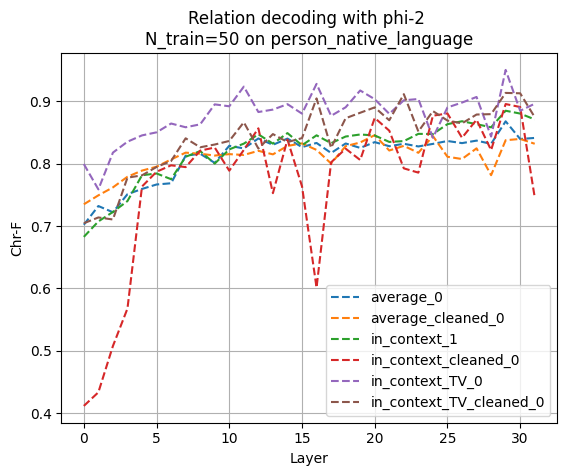

In [8]:
%cd ~/code/entityrepresentations/
import json, os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import tikzplotlib

model_name = "phi-2"
dataset_name = "CoNLL2003"
data_name = "constellation"
data_name = "landmark"
data_name = "person_native_language"

filter_N_train = 200
filter_N_train = 0
filter_N_train = 50
dir = "./scripts/RelExtractionResults"

res_files = [f for f in os.listdir(dir) if f.startswith("RelExtraction") and f.endswith(".json") and data_name in f]
print(res_files)
results_relEx = []

for res_file in res_files:
    #load it
    path = Path(dir) / res_file
    print(path)
    with open(path, 'r') as file:
        data = json.load(file)

    cleaned  = data[0].get('cleaned', False)
    method = data[0].get('method', 'in_context')
    N_train = data[0].get('N_train', 10)
    layers = [d['layer'] for d in data]

    EM = [d['metrics']['Exact Match'] for d in data]
    chrf = [d['metrics']['Chr-F']/100 for d in data]
    partial = [d['metrics']['Partial Match'] for d in data]
    label = res_file.split('.json')[0].split(model_name + "_")[-1]
    results_relEx.append(
        {
            "method": method,
            "N_train": N_train,
            "cleaned": cleaned,
            "label": label,
            "file": res_file,
            "data" : data,
        }
    )
    if not filter_N_train or N_train == filter_N_train:
        # plt.plot(EM, 'o-', label=label)
        plt.plot(chrf, '--', label=label)
        # plt.plot(partial, 'o-', label=label)
    plt.title(f"Relation decoding with {model_name} \n{f'N_train={filter_N_train}' if filter_N_train else ''} on {data_name}")
results_relEx = pd.DataFrame(results_relEx)
plt.legend()
plt.grid()
# plt.xticks(np.arange(len(EM)), layers)
plt.xlabel("Layer")
# plt.ylabel("Exact Match")
plt.ylabel("Chr-F")
tikzplotlib.save(f"./plots/RelExtraction_{data_name}_{model_name}.tex")   

In [ ]:
results_relEx.head()

,method,N_train,cleaned,label,file,data
0,average,50,False,average_0,RelExtraction_landmark_in_country_phi-2_averag...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
1,average,50,True,average_cleaned_0,RelExtraction_landmark_in_country_phi-2_averag...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
2,in_context,50,True,in_context_cleaned_0,RelExtraction_landmark_in_country_phi-2_in_con...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
3,average,50,False,average_1,RelExtraction_landmarks_phi-2_average_1.json,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
4,average,200,False,average_3,RelExtraction_landmarks_phi-2_average_3.json,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."


In [ ]:
import numpy as np
t_layer = 30

method = 'in_context'
cleaned = True

filtered_data = results_relEx[(results_relEx['method']==method) & (results_relEx['cleaned']==cleaned) & (results_relEx['N_train']==filter_N_train)]
#filter out the layer
data = [d for d in filtered_data["data"].values[-1] if d['layer'] == t_layer][0]

#print metrics
print(filtered_data['file'].values)
print(f"data for layer {t_layer} and method {method} on {data_name}")
print(data['metrics'])

#print infernce 
inference = data['inference']
columns = ['subject', 'object', 'inferred']
print(f"{'Subject'.center(45)}|{'Object'.center(25)}|{'Inferred'.center(25)}")
print("="*100)

for i in range(30):
    item = inference[np.random.randint(len(inference))]
    s = item['subject']
    o = item['object']
    print(f"{s.center(45)}|{o.center(25)}|{item['inferred'].center(25)}")

['RelExtraction_landmark_in_country_phi-2_in_context_cleaned_0.json']
data for layer 30 and method in_context on landmark
{'Partial Match': 0.7015810276679841, 'Exact Match': 0.6996047430830039, 'Chr-F': 67.45742540993459, 'Version': 1.2}
                   Subject                   |          Object         |         Inferred        
            Bahujan Vikas Aaghadi            |          India          |          India          
             Spanish Armed Forces            |          Spain          |         America         
               Kyōto Prefecture              |          Japan          |          Japan          
                     .af                     |       Afghanistan       |         America         
                   Medaram                   |          India          |          India          
                   Capolago                  |       Switzerland       |          Italy          
                  Rio Quente                 |          Brazil         |   